<a href="https://colab.research.google.com/github/realshubhamraut/CDAC-DBDA-coursework/blob/main/06.big-data-technologies/assignments/team_project_spark_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AXISBANK Stock Market Analysis with PySpark

## Project Overview
Comprehensive stock market analysis using **PySpark RDD, DataFrame, and SQL APIs** to demonstrate:
- Low-level distributed computing (RDD API)
- High-level data operations (DataFrame API)  
- Declarative queries (SQL API)

## Dataset
- **Stock:** AXISBANK.NS (NSE India)
- **Source:** GitHub repository
- **Features:** Date, Open, High, Low, Close, Adj Close, Volume

## Analysis Phases
1. **Data Understanding** - Schema, statistics, data quality
2. **Data Cleaning** - Type conversion, feature engineering
3. **Exploratory Analysis** - Patterns, volatility, volume analysis
4. **Correlation Analysis** - Price-volume relationships, trends
5. **Advanced Analysis** - Alerts, signals, forecasting
6. **Strategic Insights** - Investment recommendations
7. **Visualization** - Publication-ready charts

---

In [4]:
import os
def install_java():
  !apt-get install -y openjdk-8-jdk-headless -qq > /dev/null
  os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
  !java -version
install_java()

openjdk version "1.8.0_462"
OpenJDK Runtime Environment (build 1.8.0_462-8u462-ga~us1-0ubuntu2~22.04.2-b08)
OpenJDK 64-Bit Server VM (build 25.462-b08, mixed mode)


In [5]:
!pip install pyspark

In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_date, trim
from pyspark.sql.types import DoubleType, LongType
import os


file_path = "/content/AXISBANK.csv"
url = "https://raw.githubusercontent.com/realshubhamraut/CDAC-DBDA-coursework/main/06.big-data-technologies/data/AXISBANK.csv"


if not os.path.exists(file_path):
    !wget -q {url} -O {file_path}
    print(" Dataset downloaded")
else:
    print("Dataset already available")




Dataset already available


In [42]:
!pip install pyspark

from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("AxisStockAnalysis").getOrCreate()

In [9]:

# read every columns as strings
df_raw = spark.read.csv(file_path, header=True, inferSchema=False)
print(f"\n  Raw data loaded: {df_raw.count()} rows")
print(f"   Columns: {df_raw.columns}")



  Raw data loaded: 6493 rows
   Columns: ['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


In [10]:

# remove rows where Close = "AXISBANK.NS" (ticker row)
# remove rows where Price = "Date" or empty (header row)
df_filtered = df_raw.filter(
    (trim(col("Close")) != "AXISBANK.NS") &
    (trim(col("Price")) != "Date") &
    (trim(col("Price")) != "") &
    col("Price").isNotNull()
)
print(f"  After filtering: {df_filtered.count()} rows")



  After filtering: 6491 rows


In [17]:
# cast to proper types

df = df_filtered.select(
    to_date(col("Price")).alias("Date"),  # Price → Date conversion
    col("Open").cast(DoubleType()).alias("Open"),
    col("High").cast(DoubleType()).alias("High"),
    col("Low").cast(DoubleType()).alias("Low"),
    col("Close").cast(DoubleType()).alias("Close"),
    col("Adj Close").cast(DoubleType()).alias("Adj Close"),
    col("Volume").cast(LongType()).alias("Volume")
)


df = df.dropna()
final_count = df.count()
print(f"After type casting & NULL removal: {final_count} rows")


print(f"{final_count:,} clean rows loaded")

After type casting & NULL removal: 6491 rows
6,491 clean rows loaded


In [18]:
df.show(5, truncate=False)


+----------+------------------+------------------+------------------+------------------+------------------+------+
|Date      |Open              |High              |Low               |Close             |Adj Close         |Volume|
+----------+------------------+------------------+------------------+------------------+------------------+------+
|1998-11-27|3.549999952316284 |3.549999952316284 |2.7100000381469727|3.4000000953674316|2.2513718605041504|21000 |
|1998-11-30|3.25              |3.299999952316284 |3.0999999046325684|3.2100000381469727|2.125559091567993 |132000|
|1998-12-01|3.2899999618530273|3.4600000381469727|3.2200000286102295|3.390000104904175 |2.2447493076324463|123500|
|1998-12-02|3.359999895095825 |3.440000057220459 |3.319999933242798 |3.390000104904175 |2.2447493076324463|75500 |
|1998-12-03|3.440000057220459 |3.490000009536743 |3.369999885559082 |3.390000104904175 |2.2447493076324463|102000|
+----------+------------------+------------------+------------------+-----------

In [19]:
df.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Adj Close: double (nullable = true)
 |-- Volume: long (nullable = true)



In [33]:
import pyspark.sql.functions as F
# checking for 0 and -ve values
zero_or_negative = df.filter(
    (col("Close") <= 0) |
    (col("Open") <= 0) |
    (col("High") <= 0) |
    (col("Low") <= 0)
)
zero_count = zero_or_negative.count()
print(f"no of negative/zero values: {zero_count}")

no of negative/zero values: 0


## Phase 1: Project Setup and Data Understanding

Explore data structure, column types, basic stats


In [39]:
df.show(10, truncate=False)

+----------+------------------+------------------+------------------+------------------+------------------+------+
|Date      |Open              |High              |Low               |Close             |Adj Close         |Volume|
+----------+------------------+------------------+------------------+------------------+------------------+------+
|1998-11-27|3.549999952316284 |3.549999952316284 |2.7100000381469727|3.4000000953674316|2.2513718605041504|21000 |
|1998-11-30|3.25              |3.299999952316284 |3.0999999046325684|3.2100000381469727|2.125559091567993 |132000|
|1998-12-01|3.2899999618530273|3.4600000381469727|3.2200000286102295|3.390000104904175 |2.2447493076324463|123500|
|1998-12-02|3.359999895095825 |3.440000057220459 |3.319999933242798 |3.390000104904175 |2.2447493076324463|75500 |
|1998-12-03|3.440000057220459 |3.490000009536743 |3.369999885559082 |3.390000104904175 |2.2447493076324463|102000|
|1998-12-04|3.3399999141693115|3.4100000858306885|3.299999952316284 |3.390000104

In [38]:
df.printSchema()
print(f"\nTotal columns: {len(df.columns)}")
print(f"Column names: {df.columns}")

root
 |-- Date: date (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Adj Close: double (nullable = true)
 |-- Volume: long (nullable = true)


Total columns: 7
Column names: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [40]:
df.describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+-----------------+
|summary|              Open|              High|               Low|             Close|         Adj Close|           Volume|
+-------+------------------+------------------+------------------+------------------+------------------+-----------------+
|  count|              6491|              6491|              6491|              6491|              6491|             6491|
|   mean|331.87688215027566|  336.302203618145|327.01741565627356|331.61883222753767|324.10840870780913|7626391.699738099|
| stddev|318.52665511905906|321.78661438311843| 315.0007517488669|318.40003167157835| 319.5417476982824|8629970.420217369|
|    min|2.4700000286102295|2.4700000286102295|2.4600000381469727|2.4700000286102295|1.6355550289154053|                0|
|    max| 1316.699951171875|1339.6500244140625|            1305.0| 1317.300048828125| 1317.300048828125|        120541914|
+-------+-------

In [45]:

# convert DataFrame to RDD
rdd = df.rdd

print(f"no of partitions: {rdd.getNumPartitions()}")
print(f"total no of records: {rdd.count()}")



no of partitions: 1
total no of records: 6491
Row(Date=datetime.date(1998, 11, 27), Open=3.549999952316284, High=3.549999952316284, Low=2.7100000381469727, Close=3.4000000953674316, Adj Close=2.2513718605041504, Volume=21000)
Row(Date=datetime.date(1998, 11, 30), Open=3.25, High=3.299999952316284, Low=3.0999999046325684, Close=3.2100000381469727, Adj Close=2.125559091567993, Volume=132000)
Row(Date=datetime.date(1998, 12, 1), Open=3.2899999618530273, High=3.4600000381469727, Low=3.2200000286102295, Close=3.390000104904175, Adj Close=2.2447493076324463, Volume=123500)


In [46]:
for row in rdd.take(3):
    print(row)


Row(Date=datetime.date(1998, 11, 27), Open=3.549999952316284, High=3.549999952316284, Low=2.7100000381469727, Close=3.4000000953674316, Adj Close=2.2513718605041504, Volume=21000)
Row(Date=datetime.date(1998, 11, 30), Open=3.25, High=3.299999952316284, Low=3.0999999046325684, Close=3.2100000381469727, Adj Close=2.125559091567993, Volume=132000)
Row(Date=datetime.date(1998, 12, 1), Open=3.2899999618530273, High=3.4600000381469727, Low=3.2200000286102295, Close=3.390000104904175, Adj Close=2.2447493076324463, Volume=123500)


In [47]:

# extract close prices
close_prices = rdd.map(lambda row: float(row['Close']) if row['Close'] is not None else 0.0)

In [49]:
# calculate stats
total_count = close_prices.count()
sum_prices = close_prices.reduce(lambda a, b: a + b)
mean_price = sum_prices / total_count
max_price = close_prices.reduce(lambda a, b: a if a > b else b)
min_price = close_prices.reduce(lambda a, b: a if a < b else b)
#here we used conditional instead of min/max to avoid conflict with python

print(f"Close Price Statistics:")
print(f"  Count: {total_count}")
print(f"  Mean: {mean_price:.2f}")
print(f"  Max: {max_price:.2f}")
print(f"  Min: {min_price:.2f}")

Close Price Statistics:
  Count: 6491
  Mean: 331.62
  Max: 1317.30
  Min: 2.47


In [52]:
# calculate standard deviation
squared_diff = close_prices.map(lambda x: (x - mean_price) ** 2)
variance = squared_diff.reduce(lambda a, b: a + b) / total_count
std_dev = variance ** 0.5
print(f"Std Dev: {std_dev:.2f}")

Std Dev: 318.38


In [53]:
df.createOrReplaceTempView("axis_stock")

In [54]:
#check null values

spark.sql("""
SELECT
    SUM(CASE WHEN Date IS NULL THEN 1 ELSE 0 END) AS Date_NullCount,
    SUM(CASE WHEN Open IS NULL THEN 1 ELSE 0 END) AS Open_NullCount,
    SUM(CASE WHEN High IS NULL THEN 1 ELSE 0 END) AS High_NullCount,
    SUM(CASE WHEN Low IS NULL THEN 1 ELSE 0 END) AS Low_NullCount,
    SUM(CASE WHEN Close IS NULL THEN 1 ELSE 0 END) AS Close_NullCount,
    SUM(CASE WHEN Volume IS NULL THEN 1 ELSE 0 END) AS Volume_NullCount
FROM axis_stock
""").show()

+--------------+--------------+--------------+-------------+---------------+----------------+
|Date_NullCount|Open_NullCount|High_NullCount|Low_NullCount|Close_NullCount|Volume_NullCount|
+--------------+--------------+--------------+-------------+---------------+----------------+
|             0|             0|             0|            0|              0|               0|
+--------------+--------------+--------------+-------------+---------------+----------------+



In [55]:
# summary statistics for key columns
print("=== SQL API: Summary Statistics ===")
spark.sql("""
SELECT
    MIN(Close) AS Min_Close,
    MAX(Close) AS Max_Close,
    AVG(Close) AS Avg_Close,
    STDDEV(Close) AS StdDev_Close,
    MIN(Volume) AS Min_Volume,
    MAX(Volume) AS Max_Volume,
    AVG(Volume) AS Avg_Volume,
    STDDEV(Volume) AS StdDev_Volume
FROM axis_stock
""").show()

=== SQL API: Summary Statistics ===
+------------------+-----------------+------------------+------------------+----------+----------+-----------------+-----------------+
|         Min_Close|        Max_Close|         Avg_Close|      StdDev_Close|Min_Volume|Max_Volume|       Avg_Volume|    StdDev_Volume|
+------------------+-----------------+------------------+------------------+----------+----------+-----------------+-----------------+
|2.4700000286102295|1317.300048828125|331.61883222753767|318.40003167157835|         0| 120541914|7626391.699738099|8629970.420217369|
+------------------+-----------------+------------------+------------------+----------+----------+-----------------+-----------------+



---

## Phase 2: Data Cleaning and Preparation

**Objective:** Clean data and add calculated columns for analysis

In [58]:
# check for duplicates

total_rows = df.count()
unique_rows = df.dropDuplicates().count()
duplicate_count = total_rows - unique_rows
print(f"Total rows: {total_rows}")
print(f"Unique rows: {unique_rows}")
print(f"Duplicate rows: {duplicate_count}")

Total rows: 6491
Unique rows: 6491
Duplicate rows: 0


In [59]:

from pyspark.sql.functions import to_date, col


df_cleaned = df
df_cleaned.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Adj Close: double (nullable = true)
 |-- Volume: long (nullable = true)



### Task: Add Daily Returns Column

**Note:** Daily return = ((Today's Close - Yesterday's Close) / Yesterday's Close) * 100

In [61]:
# calculate daily returns
from pyspark.sql.window import Window
from pyspark.sql.functions import lag


# define window partitioned by nothing, ordered by Date
window_spec = Window.orderBy("Date")

# calculate previous day's close price
df_cleaned = df_cleaned.withColumn("Prev_Close", lag("Close", 1).over(window_spec))

# calculate daily return percentage
df_cleaned = df_cleaned.withColumn(
    "Daily_Return",
    ((col("Close") - col("Prev_Close")) / col("Prev_Close")) * 100
)

df_cleaned.select("Date", "Close", "Prev_Close", "Daily_Return").show(10)

+----------+------------------+------------------+-------------------+
|      Date|             Close|        Prev_Close|       Daily_Return|
+----------+------------------+------------------+-------------------+
|1998-11-27|3.4000000953674316|              NULL|               NULL|
|1998-11-30|3.2100000381469727|3.4000000953674316| -5.588236820326502|
|1998-12-01| 3.390000104904175|3.2100000381469727| 5.6074786485395265|
|1998-12-02| 3.390000104904175| 3.390000104904175|                0.0|
|1998-12-03| 3.390000104904175| 3.390000104904175|                0.0|
|1998-12-04| 3.390000104904175| 3.390000104904175|                0.0|
|1998-12-07| 3.380000114440918| 3.390000104904175|-0.2949849602892418|
|1998-12-08| 3.240000009536743| 3.380000114440918| -4.142014797751925|
|1998-12-09| 3.240000009536743| 3.240000009536743|                0.0|
|1998-12-10| 3.200000047683716| 3.240000009536743|-1.2345667202249964|
+----------+------------------+------------------+-------------------+
only s

In [64]:
# convert to RDD with index
rdd_with_data = df_cleaned.select("Date", "Close").rdd.sortBy(lambda x: x[0])

# collect to list for sequential processing (in production, use zipWithIndex for large data)
data_list = rdd_with_data.collect()

# calculate returns
returns_data = []
for i in range(len(data_list)):
    date = data_list[i][0]
    close = data_list[i][1]
    if i == 0:
        returns_data.append((date, close, None, None))
    else:
        prev_close = data_list[i-1][1]
        daily_return = ((close - prev_close) / prev_close) * 100
        returns_data.append((date, close, prev_close, daily_return))

# create RDD from computed returns
returns_rdd = spark.sparkContext.parallelize(returns_data)

print("First 10 rows with daily returns (Date, Close, Prev_Close, Daily_Return):")
for row in returns_rdd.take(10):
    print(f"{row[0]}: Close={row[1]:.2f}, Prev={row[2]}, Return={row[3]}")

First 10 rows with daily returns (Date, Close, Prev_Close, Daily_Return):
1998-11-27: Close=3.40, Prev=None, Return=None
1998-11-30: Close=3.21, Prev=3.4000000953674316, Return=-5.588236820326502
1998-12-01: Close=3.39, Prev=3.2100000381469727, Return=5.6074786485395265
1998-12-02: Close=3.39, Prev=3.390000104904175, Return=0.0
1998-12-03: Close=3.39, Prev=3.390000104904175, Return=0.0
1998-12-04: Close=3.39, Prev=3.390000104904175, Return=0.0
1998-12-07: Close=3.38, Prev=3.390000104904175, Return=-0.2949849602892418
1998-12-08: Close=3.24, Prev=3.380000114440918, Return=-4.142014797751925
1998-12-09: Close=3.24, Prev=3.240000009536743, Return=0.0
1998-12-10: Close=3.20, Prev=3.240000009536743, Return=-1.2345667202249964


### Task: Add Moving Averages (50-day and 200-day)

**Note:** Moving averages smooth out price fluctuations to identify trends

In [66]:
from pyspark.sql.functions import avg


# define windows for moving averages
window_50 = Window.orderBy("Date").rowsBetween(-49, 0)  # current + 49 previous rows
window_200 = Window.orderBy("Date").rowsBetween(-199, 0)  # current + 199 previous rows

# calculate moving averages
df_cleaned = df_cleaned.withColumn("SMA_50", avg("Close").over(window_50))
df_cleaned = df_cleaned.withColumn("SMA_200", avg("Close").over(window_200))

df_cleaned.select("Date", "Close", "SMA_50", "SMA_200").show(10)

+----------+------------------+------------------+------------------+
|      Date|             Close|            SMA_50|           SMA_200|
+----------+------------------+------------------+------------------+
|1998-11-27|3.4000000953674316|3.4000000953674316|3.4000000953674316|
|1998-11-30|3.2100000381469727| 3.305000066757202| 3.305000066757202|
|1998-12-01| 3.390000104904175| 3.333333412806193| 3.333333412806193|
|1998-12-02| 3.390000104904175|3.3475000858306885|3.3475000858306885|
|1998-12-03| 3.390000104904175|3.3560000896453857|3.3560000896453857|
|1998-12-04| 3.390000104904175| 3.361666758855184| 3.361666758855184|
|1998-12-07| 3.380000114440918| 3.364285809653146| 3.364285809653146|
|1998-12-08| 3.240000009536743|3.3487500846385956|3.3487500846385956|
|1998-12-09| 3.240000009536743| 3.336666742960612| 3.336666742960612|
|1998-12-10| 3.200000047683716|3.3230000734329224|3.3230000734329224|
+----------+------------------+------------------+------------------+
only showing top 10 

In [68]:
# update the SQL temp view with cleaned data
df_cleaned.createOrReplaceTempView("axis_stock_cleaned")

---

## Phase 3: Exploratory Data Analysis (EDA)

**Objective:** Explore historical trends and derive insights

In [70]:
# daily return analysis
spark.sql("""
SELECT
    AVG(Daily_Return) AS Avg_Daily_Return,
    STDDEV(Daily_Return) AS Daily_Return_StdDev,
    MIN(Daily_Return) AS Min_Daily_Return,
    MAX(Daily_Return) AS Max_Daily_Return,
    PERCENTILE_APPROX(Daily_Return, 0.25) AS Q1_Daily_Return,
    PERCENTILE_APPROX(Daily_Return, 0.50) AS Median_Daily_Return,
    PERCENTILE_APPROX(Daily_Return, 0.75) AS Q3_Daily_Return
FROM axis_stock_cleaned
WHERE Daily_Return IS NOT NULL
""").show()

+-------------------+-------------------+-------------------+-----------------+------------------+-------------------+------------------+
|   Avg_Daily_Return|Daily_Return_StdDev|   Min_Daily_Return| Max_Daily_Return|   Q1_Daily_Return|Median_Daily_Return|   Q3_Daily_Return|
+-------------------+-------------------+-------------------+-----------------+------------------+-------------------+------------------+
|0.12714462893956738|  2.751704369324395|-27.910779330500706|24.86486016267235|-1.209754491029076|                0.0|1.3121911378058797|
+-------------------+-------------------+-------------------+-----------------+------------------+-------------------+------------------+



In [71]:
# analyze volatility (standard deviation of returns)
from pyspark.sql.functions import stddev as stddev_func

volatility_df = df_cleaned.select(
    stddev_func("Daily_Return").alias("Volatility"),
    avg("Daily_Return").alias("Avg_Return")
)
volatility_df.show()
print("\nNote: Higher standard deviation indicates higher volatility (risk)")

+-----------------+-------------------+
|       Volatility|         Avg_Return|
+-----------------+-------------------+
|2.751704369324395|0.12714462893956738|
+-----------------+-------------------+


Note: Higher standard deviation indicates higher volatility (risk)


In [72]:
import builtins # import builtins module to explicitly use built-in sum


# get data sorted by date
sorted_data = df_cleaned.select("Date", "Daily_Return").orderBy("Date").rdd.collect()

# calculate 30-day rolling standard deviation
rolling_volatility = []
window_size = 30

for i in range(len(sorted_data)):
    if i >= window_size - 1:
        # get last 30 daily returns
        returns_window = [row[1] for row in sorted_data[i-window_size+1:i+1] if row[1] is not None]

        if len(returns_window) > 0:
            # calculate standard deviation
            mean_return = builtins.sum(returns_window) / len(returns_window) # Use builtins.sum
            variance = builtins.sum((x - mean_return) ** 2 for x in returns_window) / len(returns_window) # Use builtins.sum
            std_dev = variance ** 0.5
            rolling_volatility.append((sorted_data[i][0], std_dev))

print(f"Sample 30-day rolling volatility (first 5 after window filled):")
for date, vol in rolling_volatility[:5]:
    print(f"{date}: {vol:.4f}%")

Sample 30-day rolling volatility (first 5 after window filled):
1999-01-07: 3.4495%
1999-01-08: 3.4066%
1999-01-11: 3.2760%
1999-01-12: 3.1579%
1999-01-13: 3.1586%


In [74]:
# days with highest trading volume
spark.sql("""
SELECT
    Date,
    Volume,
    Close,
    Daily_Return
FROM axis_stock_cleaned
WHERE Volume IS NOT NULL
ORDER BY Volume DESC
LIMIT 10
""").show()
print("\nNote: High volume often indicates significant market events")

+----------+---------+------------------+--------------------+
|      Date|   Volume|             Close|        Daily_Return|
+----------+---------+------------------+--------------------+
|2016-08-31|120541914| 596.8499755859375|   0.964213978934483|
|2020-06-16| 96186227|381.54998779296875| -2.0662264333763916|
|2020-07-22| 89611937|478.95001220703125|   7.339757755274199|
|2013-08-30| 85220080|166.58999633789062|  -2.092270165322237|
|2016-02-29| 82022905|            375.75| -2.7436277820778763|
|2013-09-05| 73632590|             185.5|    15.7205218144042|
|2020-05-28| 72693713|390.95001220703125|   1.020674988896964|
|2020-05-27| 72430787|             387.0|  13.389983545722451|
|2020-03-27| 71042591|            359.75|   5.374928655997432|
|2020-05-06| 67511628| 388.8500061035156|-0.03855884228390103|
+----------+---------+------------------+--------------------+


Note: High volume often indicates significant market events


### Task: Seasonal Patterns Analysis

**Note:** Analyze monthly and quarterly trends

In [78]:
# monthly trends
from pyspark.sql.functions import month, year, quarter

df_monthly = df_cleaned.withColumn("Month", month("Date")) \
                       .withColumn("Year", year("Date"))

monthly_stats = df_monthly.groupBy("Year", "Month") \
    .agg(
        avg("Close").alias("Avg_Close"),
        avg("Volume").alias("Avg_Volume"),
        avg("Daily_Return").alias("Avg_Return")
    ) \
    .orderBy("Year", "Month")

monthly_stats.show(24)

+----+-----+------------------+------------------+--------------------+
|Year|Month|         Avg_Close|        Avg_Volume|          Avg_Return|
+----+-----+------------------+------------------+--------------------+
|1998|   11| 3.305000066757202|           76500.0|  -5.588236820326502|
|1998|   12|3.1813043822412905|39673.913043478264|  0.0893660315279008|
|1999|    1| 3.287142867133731|56452.380952380954| -0.2816748417610428|
|1999|    2|3.0230000019073486|           23850.0|-0.24099333847329057|
|1999|    3| 2.933043448821358| 70695.65217391304|0.017391112346686284|
|1999|    4|2.6204545497894287| 8863.636363636364| -0.3351566053301621|
|1999|    5| 2.770000003633045|30166.666666666668|  0.4213384178984668|
|1999|    6| 3.024545441974293| 50613.63636363636|  0.5706681772182455|
|1999|    7| 3.401818188753995| 73159.09090909091| 0.41121906631050853|
|1999|    8|3.4713636311617764| 79136.36363636363|  0.5359335060432884|
|1999|    9|3.5536363233219492|41431.818181818184|-0.25021129044

In [79]:
# quarterly analysis
spark.sql("""
SELECT
    YEAR(Date) AS Year,
    QUARTER(Date) AS Quarter,
    AVG(Close) AS Avg_Close,
    AVG(Volume) AS Avg_Volume,
    MIN(Close) AS Min_Close,
    MAX(Close) AS Max_Close
FROM axis_stock_cleaned
GROUP BY YEAR(Date), QUARTER(Date)
ORDER BY Year, Quarter
""").show()

+----+-------+------------------+------------------+------------------+------------------+
|Year|Quarter|         Avg_Close|        Avg_Volume|         Min_Close|         Max_Close|
+----+-------+------------------+------------------+------------------+------------------+
|1998|      4|3.1912000370025635|           42620.0|               3.0|3.4100000858306885|
|1999|      1|3.0773437432944775|        51382.8125| 2.619999885559082| 3.509999990463257|
|1999|      2| 2.805538459924551|29876.923076923078|2.4700000286102295|3.4000000953674316|
|1999|      3|3.4756060477459068|64575.757575757576|3.0999999046325684| 3.930000066757202|
|1999|      4|3.8292424281438193| 169356.0606060606|3.1500000953674316| 5.610000133514404|
|2000|      1|6.3719999973590555|410730.53846153844| 4.679999828338623| 8.399999618530273|
|2000|      2| 6.962923115950364|          117224.0| 6.340000152587891| 7.800000190734863|
|2000|      3| 7.559076888744648|195795.53846153847| 6.639999866485596| 8.449999809265137|

In [81]:
import builtins
# extract month and close price
month_close_rdd = df_cleaned.select("Date", "Close").rdd \
    .map(lambda row: (row[0].month, float(row[1])))

# group by month and calculate average
monthly_avg = month_close_rdd.groupByKey() \
    .mapValues(lambda values: builtins.sum(values) / len(list(values))) \
    .sortByKey()

print("Average Close Price by Month:")
for month_num, avg_close in monthly_avg.collect():
    print(f"Month {month_num}: {avg_close:.2f}")


Note: RDD requires manual grouping and aggregation logic

Average Close Price by Month:
Month 1: 328.77
Month 2: 333.95
Month 3: 313.08
Month 4: 316.48
Month 5: 327.60
Month 6: 333.65
Month 7: 343.66
Month 8: 337.05
Month 9: 346.14
Month 10: 345.58
Month 11: 335.78
Month 12: 317.13


---

## Phase 4: Correlation and Trend Analysis

**Objective:** Investigate relationships between variables and detect trends

### Task: Calculate Correlation between Volume and Price

**Note:** Correlation ranges from -1 to +1
- +1: Perfect positive correlation
- 0: No correlation
- -1: Perfect negative correlation

In [82]:
# calculate correlations

close_volume_corr = df_cleaned.stat.corr("Close", "Volume")
print(f"Correlation between Close and Volume: {close_volume_corr:.4f}")

# additional correlations
open_close_corr = df_cleaned.stat.corr("Open", "Close")
high_close_corr = df_cleaned.stat.corr("High", "Close")
low_close_corr = df_cleaned.stat.corr("Low", "Close")

print(f"Correlation between Open and Close: {open_close_corr:.4f}")
print(f"Correlation between High and Close: {high_close_corr:.4f}")
print(f"Correlation between Low and Close: {low_close_corr:.4f}")

Correlation between Close and Volume: 0.3328
Correlation between Open and Close: 0.9997
Correlation between High and Close: 0.9999
Correlation between Low and Close: 0.9999


In [83]:
# sql correlation matrix
spark.sql("""
SELECT
    corr(Open, Close) AS Open_Close_Correlation,
    corr(High, Close) AS High_Close_Correlation,
    corr(Low, Close) AS Low_Close_Correlation,
    corr(Volume, Close) AS Volume_Close_Correlation
FROM axis_stock_cleaned
""").show()

+----------------------+----------------------+---------------------+------------------------+
|Open_Close_Correlation|High_Close_Correlation|Low_Close_Correlation|Volume_Close_Correlation|
+----------------------+----------------------+---------------------+------------------------+
|    0.9997123632853775|    0.9998755565419127|   0.9998613784259928|      0.3328361713568703|
+----------------------+----------------------+---------------------+------------------------+



In [85]:
# manual correlation calculation

print("\nNote: Correlation = Cov(X,Y) / (StdDev(X) * StdDev(Y))\n")

# extract Close and Volume as pairs
close_volume_pairs = df_cleaned.select("Close", "Volume").rdd \
    .map(lambda row: (float(row[0]), float(row[1])))

n = close_volume_pairs.count()

# calculate means
sum_close = close_volume_pairs.map(lambda x: x[0]).reduce(lambda a, b: a + b)
sum_volume = close_volume_pairs.map(lambda x: x[1]).reduce(lambda a, b: a + b)
mean_close = sum_close / n
mean_volume = sum_volume / n

# calculate covariance
cov = close_volume_pairs.map(lambda x: (x[0] - mean_close) * (x[1] - mean_volume)) \
    .reduce(lambda a, b: a + b) / n

# calculate standard deviations
std_close = (close_volume_pairs.map(lambda x: (x[0] - mean_close) ** 2) \
    .reduce(lambda a, b: a + b) / n) ** 0.5
std_volume = (close_volume_pairs.map(lambda x: (x[1] - mean_volume) ** 2) \
    .reduce(lambda a, b: a + b) / n) ** 0.5

# calculate correlation
correlation = cov / (std_close * std_volume)

print(f"Manual RDD Correlation (Close vs Volume): {correlation:.4f}")
print(f"Mean Close: {mean_close:.2f}, StdDev: {std_close:.2f}")
print(f"Mean Volume: {mean_volume:.2f}, StdDev: {std_volume:.2f}")


Note: Correlation = Cov(X,Y) / (StdDev(X) * StdDev(Y))

Manual RDD Correlation (Close vs Volume): 0.3328
Mean Close: 331.62, StdDev: 318.38
Mean Volume: 7626391.70, StdDev: 8629305.63


### Task: Moving Average Crossover Strategy

**Note:**
- **Golden Cross**: SMA_50 crosses above SMA_200 (Bullish signal)
- **Death Cross**: SMA_50 crosses below SMA_200 (Bearish signal)

In [86]:
# identify trend using moving averages
spark.sql("""
SELECT
    Date,
    Close,
    SMA_50,
    SMA_200,
    CASE
        WHEN SMA_50 > SMA_200 THEN 'Uptrend (Bullish)'
        WHEN SMA_50 < SMA_200 THEN 'Downtrend (Bearish)'
        ELSE 'Neutral'
    END AS Trend
FROM axis_stock_cleaned
WHERE SMA_50 IS NOT NULL AND SMA_200 IS NOT NULL
ORDER BY Date DESC
LIMIT 20
""").show(truncate=False)

+----------+------------------+------------------+------------------+-----------------+
|Date      |Close             |SMA_50            |SMA_200           |Trend            |
+----------+------------------+------------------+------------------+-----------------+
|2024-11-13|1139.1500244140625|1188.4909936523438|1153.4754986572266|Uptrend (Bullish)|
|2024-11-12|1158.1500244140625|1189.5399926757811|1153.3624987792969|Uptrend (Bullish)|
|2024-11-11|1171.0            |1190.1529931640625|1153.0592486572266|Uptrend (Bullish)|
|2024-11-08|1160.949951171875 |1190.2379931640626|1152.6157489013672|Uptrend (Bullish)|
|2024-11-07|1159.9000244140625|1190.5269946289063|1152.4064990234374|Uptrend (Bullish)|
|2024-11-06|1166.5            |1190.7479931640626|1152.2044989013673|Uptrend (Bullish)|
|2024-11-05|1171.699951171875 |1191.0429931640624|1151.9737487792968|Uptrend (Bullish)|
|2024-11-04|1139.25           |1191.0149951171875|1151.7439990234375|Uptrend (Bullish)|
|2024-11-01|1169.550048828125 |1

In [89]:
# trend indicator
from pyspark.sql.functions import when

df_with_trend = df_cleaned.withColumn(
    "Trend",
    when(col("SMA_50") > col("SMA_200"), "Uptrend")
    .when(col("SMA_50") < col("SMA_200"), "Downtrend")
    .otherwise("Neutral")
)

# count trend distribution
trend_counts = df_with_trend.groupBy("Trend").count().orderBy("count", ascending=False)
print("\nTrend Distribution:")
trend_counts.show()


Trend Distribution:
+---------+-----+
|    Trend|count|
+---------+-----+
|  Uptrend| 4382|
|Downtrend| 2059|
|  Neutral|   50|
+---------+-----+



### Task: Bollinger Bands Analysis

**Note:** Bollinger Bands = SMA ± (2 × Standard Deviation)
- Price near upper band: Potentially overbought
- Price near lower band: Potentially oversold

In [90]:
# DataFrame API: Calculate Bollinger Bands (20-day)

window_20 = Window.orderBy("Date").rowsBetween(-19, 0)

# 20-day SMA and standard deviation
df_bollinger = df_cleaned.withColumn("BB_Middle", avg("Close").over(window_20))
df_bollinger = df_bollinger.withColumn("BB_StdDev", stddev_func("Close").over(window_20))

# upper and lower bands
df_bollinger = df_bollinger.withColumn("BB_Upper", col("BB_Middle") + (2 * col("BB_StdDev")))
df_bollinger = df_bollinger.withColumn("BB_Lower", col("BB_Middle") - (2 * col("BB_StdDev")))

# add signal
df_bollinger = df_bollinger.withColumn(
    "BB_Signal",
    when(col("Close") > col("BB_Upper"), "Overbought")
    .when(col("Close") < col("BB_Lower"), "Oversold")
    .otherwise("Normal")
)

df_bollinger.select("Date", "Close", "BB_Lower", "BB_Middle", "BB_Upper", "BB_Signal") \
    .orderBy("Date", ascending=False).show(10)

+----------+------------------+------------------+------------------+------------------+---------+
|      Date|             Close|          BB_Lower|         BB_Middle|          BB_Upper|BB_Signal|
+----------+------------------+------------------+------------------+------------------+---------+
|2024-11-13|1139.1500244140625|1132.7097786469735| 1166.820001220703|1200.9302237944325|   Normal|
|2024-11-12|1158.1500244140625|1135.2843451892527|1167.5224975585938| 1199.760649927935|   Normal|
|2024-11-11|            1171.0|1134.7503783201403|1167.3074951171875|1199.8646119142347|   Normal|
|2024-11-08| 1160.949951171875|  1134.44083696183|1166.9749938964844|1199.5091508311389|   Normal|
|2024-11-07|1159.9000244140625|1135.0577259491536|1167.5499938964845|1200.0422618438154|   Normal|
|2024-11-06|            1166.5|1135.6631198752962|1168.7674926757813|1201.8718654762665|   Normal|
|2024-11-05| 1171.699951171875|1135.8580125017158|1168.9499938964843|1202.0419752912528|   Normal|
|2024-11-0

In [91]:
# find overbought/oversold signals
df_bollinger.createOrReplaceTempView("bollinger_analysis")

spark.sql("""
SELECT
    BB_Signal,
    COUNT(*) AS Count,
    AVG(Close) AS Avg_Close,
    AVG(Daily_Return) AS Avg_Return
FROM bollinger_analysis
WHERE BB_Signal IN ('Overbought', 'Oversold')
GROUP BY BB_Signal
""").show()

+----------+-----+------------------+------------------+
| BB_Signal|Count|         Avg_Close|        Avg_Return|
+----------+-----+------------------+------------------+
|Overbought|  460| 324.6726087974465| 3.300417283719467|
|  Oversold|  281|328.78060496998853|-3.241710665518961|
+----------+-----+------------------+------------------+



### Task: Detect Anomalous Price Movements

**Note:** Identify days with returns beyond 3 standard deviations (outliers)

In [92]:
# detect outliers
spark.sql("""
SELECT
    Date,
    Close,
    Daily_Return,
    Volume
FROM axis_stock_cleaned
WHERE Daily_Return IS NOT NULL
    AND ABS(Daily_Return) > (
        SELECT AVG(Daily_Return) + 3 * STDDEV(Daily_Return)
        FROM axis_stock_cleaned
        WHERE Daily_Return IS NOT NULL
    )
ORDER BY ABS(Daily_Return) DESC
LIMIT 15
""").show(truncate=False)

+----------+------------------+-------------------+--------+
|Date      |Close             |Daily_Return       |Volume  |
+----------+------------------+-------------------+--------+
|2020-03-23|308.6499938964844 |-27.910779330500706|37622635|
|1999-12-06|4.619999885559082 |24.86486016267235  |536000  |
|1999-03-03|3.509999990463257 |23.591552695166808 |102500  |
|2003-12-03|23.0              |20.041754609442492 |7206705 |
|2003-07-03|11.5600004196167  |20.041539794808504 |5637970 |
|1999-07-19|3.930000066757202 |19.8170762511324   |306000  |
|2020-04-07|388.8500061035156 |19.48071639836142  |48093237|
|2008-10-13|131.99000549316406|19.42635677002131  |22362115|
|2003-07-07|12.859999656677246|18.74422665994369  |13238210|
|2009-05-18|155.67999267578125|18.01091179246936  |344055  |
|2004-05-17|22.06999969482422 |-15.987821430350266|340480  |
|2013-09-05|185.5             |15.7205218144042   |73632590|
|2004-02-03|27.799999237060547|-15.60412751651038 |2819440 |
|1999-06-23|3.4000000953

In [93]:
# calculate threshold
stats = df_cleaned.select(
    avg("Daily_Return").alias("mean"),
    stddev_func("Daily_Return").alias("std")
).collect()[0]

mean_return = stats['mean']
std_return = stats['std']
threshold = 3

print(f"Mean Daily Return: {mean_return:.4f}%")
print(f"Std Dev: {std_return:.4f}%")
print(f"Outlier threshold: ±{threshold} std dev = ±{threshold * std_return:.4f}%\n")

# Mark anomalies
df_anomalies = df_cleaned.withColumn(
    "Is_Anomaly",
    when(
        (col("Daily_Return") > mean_return + (threshold * std_return)) |
        (col("Daily_Return") < mean_return - (threshold * std_return)),
        "Yes"
    ).otherwise("No")
)

anomaly_count = df_anomalies.filter(col("Is_Anomaly") == "Yes").count()
total_count = df_anomalies.filter(col("Daily_Return").isNotNull()).count()
print(f"Anomalies detected: {anomaly_count} out of {total_count} days ({anomaly_count/total_count*100:.2f}%)")

Mean Daily Return: 0.1271%
Std Dev: 2.7517%
Outlier threshold: ±3 std dev = ±8.2551%

Anomalies detected: 75 out of 6490 days (1.16%)


In [94]:

# find extreme movements

# donvert to RDD and filter
extreme_movements_rdd = df_cleaned.select("Date", "Close", "Daily_Return").rdd \
    .filter(lambda row: row[2] is not None) \
    .filter(lambda row: builtins.abs(row[2]) > builtins.abs(mean_return) + (threshold * std_return)) \
    .map(lambda row: (row[0], row[1], row[2]))

print(f"Top 10 extreme movements:")
sorted_extremes = sorted(extreme_movements_rdd.collect(), key=lambda x: builtins.abs(x[2]), reverse=True)
for date, close, ret in sorted_extremes[:10]:
    print(f"{date}: Close={close:.2f}, Return={ret:.2f}%")

Top 10 extreme movements:
2020-03-23: Close=308.65, Return=-27.91%
1999-12-06: Close=4.62, Return=24.86%
1999-03-03: Close=3.51, Return=23.59%
2003-12-03: Close=23.00, Return=20.04%
2003-07-03: Close=11.56, Return=20.04%
1999-07-19: Close=3.93, Return=19.82%
2020-04-07: Close=388.85, Return=19.48%
2008-10-13: Close=131.99, Return=19.43%
2003-07-07: Close=12.86, Return=18.74%
2009-05-18: Close=155.68, Return=18.01%


---

## Phase 5: Advanced Analysis - Price Alerts & Volume Analysis

**Objective:** Implement real-time monitoring concepts and volume-price relationship

### Task: Price Alert System

**Note:** Identify days when price changes exceed threshold (e.g., ±5%)

In [95]:
# price alert system

alert_threshold = 5.0  # 5% change
print(f"Alert threshold: ±{alert_threshold}%\n")

df_alerts = df_cleaned.withColumn(
    "Alert",
    when(col("Daily_Return") > alert_threshold, "STRONG BUY SIGNAL")
    .when(col("Daily_Return") < -alert_threshold, "STRONG SELL SIGNAL")
    .otherwise("No Alert")
)

# filter alerts
alerts_triggered = df_alerts.filter(col("Alert") != "No Alert") \
    .select("Date", "Close", "Daily_Return", "Volume", "Alert") \
    .orderBy("Date", ascending=False)

print(f"Total alerts triggered: {alerts_triggered.count()}\n")
alerts_triggered.show(20, truncate=False)

Alert threshold: ±5.0%

Total alerts triggered: 432

+----------+------------------+------------------+--------+------------------+
|Date      |Close             |Daily_Return      |Volume  |Alert             |
+----------+------------------+------------------+--------+------------------+
|2024-10-18|1196.8499755859375|5.742810566952632 |20829666|STRONG BUY SIGNAL |
|2024-07-25|1175.9000244140625|-5.111960910707081|32979871|STRONG SELL SIGNAL|
|2024-06-04|1131.25           |-7.570064757406827|24135989|STRONG SELL SIGNAL|
|2024-06-03|1223.9000244140625|5.313427587039235 |22197339|STRONG BUY SIGNAL |
|2024-04-25|1127.0            |5.995767693392899 |46136295|STRONG BUY SIGNAL |
|2022-10-21|900.4000244140625 |9.027069205303544 |58057724|STRONG BUY SIGNAL |
|2022-04-29|728.5999755859375 |-6.565787767186332|34401710|STRONG SELL SIGNAL|
|2022-03-07|667.5499877929688 |-6.636365343640735|20147061|STRONG SELL SIGNAL|
|2022-02-24|730.2999877929688 |-6.034485805124927|13085009|STRONG SELL SIGNAL|

In [96]:

alerts_rdd = df_cleaned.select("Date", "Close", "Daily_Return", "Volume").rdd \
    .filter(lambda row: row[2] is not None) \
    .filter(lambda row: builtins.abs(row[2]) > alert_threshold) \
    .map(lambda row: {
        'Date': row[0],
        'Close': row[1],
        'Daily_Return': row[2],
        'Volume': row[3],
        'Alert_Type': 'BUY' if row[2] > 0 else 'SELL'
    })

alerts_list = alerts_rdd.collect()
print(f"Total alerts from RDD: {len(alerts_list)}\n")
print("Sample alerts:")
for alert in sorted(alerts_list, key=lambda x: builtins.abs(x['Daily_Return']), reverse=True)[:5]:
    print(f"{alert['Date']}: {alert['Alert_Type']} - Return: {alert['Daily_Return']:.2f}%")

Total alerts from RDD: 432

Sample alerts:
2020-03-23: SELL - Return: -27.91%
1999-12-06: BUY - Return: 24.86%
1999-03-03: BUY - Return: 23.59%
2003-12-03: BUY - Return: 20.04%
2003-07-03: BUY - Return: 20.04%


### Task: Volume-Price Relationship Analysis

**Note:** Analyze if high volume days correlate with significant price changes

In [97]:
# categorize volume and analyze relationship
from pyspark.sql.functions import ntile, avg, stddev as stddev_func, count

# categorize volume into quartiles
window_vol = Window.orderBy("Volume")
df_volume_analysis = df_cleaned.withColumn("Volume_Quartile", ntile(4).over(window_vol))

# analyze returns by volume quartile
volume_impact = df_volume_analysis.groupBy("Volume_Quartile") \
    .agg(
        avg("Daily_Return").alias("Avg_Return"),
        avg("Volume").alias("Avg_Volume"),
        stddev_func("Daily_Return").alias("Return_Volatility"),
        count("*").alias("Days")
    ) \
    .orderBy("Volume_Quartile")

print("\nQuartile 1 = Lowest Volume, Quartile 4 = Highest Volume\n")
volume_impact.show()


Quartile 1 = Lowest Volume, Quartile 4 = Highest Volume

+---------------+--------------------+-------------------+------------------+----+
|Volume_Quartile|          Avg_Return|         Avg_Volume| Return_Volatility|Days|
+---------------+--------------------+-------------------+------------------+----+
|              1|0.037485225127189395|  348314.8034504005|3.0011490664310227|1623|
|              2| 0.14024903223465293| 3796884.9235982746| 2.387983939358822|1623|
|              3| 0.07345803134876407|  7898673.696241528| 2.005668534019153|1623|
|              4|   0.257411246896181|1.846837358631319E7|3.3977511936302114|1622|
+---------------+--------------------+-------------------+------------------+----+



In [98]:
# high volume days analysis
spark.sql("""
WITH volume_stats AS (
    SELECT
        PERCENTILE_APPROX(Volume, 0.75) AS high_volume_threshold
    FROM axis_stock_cleaned
),
categorized_data AS (
    SELECT
        Date,
        Volume,
        Daily_Return,
        CASE
            WHEN Volume > (SELECT high_volume_threshold FROM volume_stats) THEN 'High Volume'
            ELSE 'Normal/Low Volume'
        END AS Volume_Category
    FROM axis_stock_cleaned
    WHERE Daily_Return IS NOT NULL
)
SELECT
    Volume_Category,
    COUNT(*) AS Days,
    AVG(Daily_Return) AS Avg_Return,
    STDDEV(Daily_Return) AS Return_StdDev,
    AVG(ABS(Daily_Return)) AS Avg_Abs_Return
FROM categorized_data
GROUP BY Volume_Category
""").show()

+-----------------+----+-------------------+------------------+-----------------+
|  Volume_Category|Days|         Avg_Return|     Return_StdDev|   Avg_Abs_Return|
+-----------------+----+-------------------+------------------+-----------------+
|Normal/Low Volume|4867|0.08406564082109694|2.4986936851958244|1.659345345027647|
|      High Volume|1623|0.25632850766575166| 3.396983702792344|2.480126904357801|
+-----------------+----+-------------------+------------------+-----------------+



---

## Phase 5: Time-Series Forecasting (Advanced)

**Objective:** Forecast future stock prices using time-series techniques

**Note:** We'll implement:
1. Simple Moving Average Forecast
2. Exponential Moving Average (EMA)
3. Train-Test Split for validation

### Task: Train-Test Split for Time-Series

**Note:** For time-series, we use chronological split (not random)

In [99]:
# split data chronologically

# get total count
total_rows = df_cleaned.count()
train_size = int(total_rows * 0.8)  # 80% for training

print(f"Total data points: {total_rows}")
print(f"Training set: {train_size} days (80%)")
print(f"Test set: {total_rows - train_size} days (20%)")

# sort by date and add row number
from pyspark.sql.functions import row_number, monotonically_increasing_id

window_spec_train = Window.orderBy("Date")
df_with_index = df_cleaned.withColumn("row_num", row_number().over(window_spec_train))

# split based on row number
train_data = df_with_index.filter(col("row_num") <= train_size)
test_data = df_with_index.filter(col("row_num") > train_size)

print(f"\nTrain set date range: {train_data.select('Date').orderBy('Date').first()[0]} to {train_data.select('Date').orderBy('Date', ascending=False).first()[0]}")
print(f"Test set date range: {test_data.select('Date').orderBy('Date').first()[0]} to {test_data.select('Date').orderBy('Date', ascending=False).first()[0]}")

Total data points: 6491
Training set: 5192 days (80%)
Test set: 1299 days (20%)

Train set date range: 1998-11-27 to 2019-08-13
Test set date range: 2019-08-14 to 2024-11-13


### Task: Simple Moving Average Forecast

**Note:** Use the moving average from training data to predict test data

In [101]:
# moving Average Forecast
from pyspark.sql.functions import col, avg, abs

# use SMA_50 as our forecast (already calculated)
# for test data, the SMA_50 becomes our prediction for next day

# prepare test data with predictions
test_with_forecast = test_data.withColumn("Forecast_SMA", col("SMA_50"))

# calculate forecast error
test_with_forecast = test_with_forecast.withColumn(
    "Forecast_Error",
    col("Close") - col("Forecast_SMA")
).withColumn(
    "Absolute_Error",
    abs(col("Forecast_Error"))
).withColumn(
    "Percentage_Error",
    (abs(col("Forecast_Error")) / col("Close")) * 100
)

# show sample predictions
print("\nSample Forecasts vs Actual:")
test_with_forecast.select("Date", "Close", "Forecast_SMA", "Forecast_Error", "Percentage_Error") \
    .orderBy("Date").show(10)



Sample Forecasts vs Actual:
+----------+-----------------+-----------------+-------------------+------------------+
|      Date|            Close|     Forecast_SMA|     Forecast_Error|  Percentage_Error|
+----------+-----------------+-----------------+-------------------+------------------+
|2019-08-14|663.2000122070312|752.7129992675781| -89.51298706054683|13.497132903037937|
|2019-08-16|675.6500244140625|           749.77| -74.11997558593748| 10.97017285690411|
|2019-08-19|            685.0|747.3159997558594|-62.315999755859366| 9.097226241731295|
|2019-08-20|672.3499755859375|744.6829992675781| -72.33302368164061|10.758239950645354|
|2019-08-21|664.7000122070312|741.6939990234375| -76.99398681640628|11.583268452299244|
|2019-08-22|661.1500244140625|738.6209997558594| -77.47097534179693|11.717609087355747|
|2019-08-23|663.9000244140625|735.6280004882813| -71.72797607421876| 10.80403275139561|
|2019-08-26|683.7000122070312|732.8990002441407|-49.198988037109416|7.1959905161170985|
|20

In [102]:

# calculate performance metrics
metrics = test_with_forecast.select(
    avg("Absolute_Error").alias("MAE"),
    avg(col("Forecast_Error") ** 2).alias("MSE"),
    avg("Percentage_Error").alias("MAPE")
).collect()[0]

mae = metrics['MAE']
mse = metrics['MSE']
rmse = mse ** 0.5
mape = metrics['MAPE']

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Square Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 45.09
Root Mean Square Error (RMSE): 60.34
Mean Absolute Percentage Error (MAPE): 6.50%


### Task: Exponential Moving Average (EMA) Forecast

**Note:** EMA gives more weight to recent prices

In [105]:
# calculate exponential moving average
print("\nNote: EMA = α × Current_Price + (1-α) × Previous_EMA")
print("where α (smoothing factor) = 2 / (period + 1)\n")

# get sorted data
alpha = 2 / (50 + 1)  # For 50-day EMA
print(f"Smoothing factor (α): {alpha:.4f}")

# collect data for sequential processing
data_sorted = df_cleaned.select("Date", "Close").orderBy("Date").rdd.collect()

# calculate EMA
ema_values = []
ema = None

for i, (date, close) in enumerate(data_sorted):
    if i == 0:
        ema = close  # First EMA is the first close price
    else:
        ema = alpha * close + (1 - alpha) * ema
    ema_values.append((date, close, ema))



Note: EMA = α × Current_Price + (1-α) × Previous_EMA
where α (smoothing factor) = 2 / (period + 1)

Smoothing factor (α): 0.0392


In [109]:
# show sample EMA values
print("\nSample EMA values (last 10):")
for date, close, ema_val in ema_values[-10:]:
    print(f"{date}: Close={close:.2f}, EMA={ema_val:.2f}")

# convert to RDD for further processing
ema_rdd = spark.sparkContext.parallelize(ema_values)


Sample EMA values (last 10):
2024-10-31: Close=1159.55, EMA=1187.01
2024-11-01: Close=1169.55, EMA=1186.32
2024-11-04: Close=1139.25, EMA=1184.48
2024-11-05: Close=1171.70, EMA=1183.97
2024-11-06: Close=1166.50, EMA=1183.29
2024-11-07: Close=1159.90, EMA=1182.37
2024-11-08: Close=1160.95, EMA=1181.53
2024-11-11: Close=1171.00, EMA=1181.12
2024-11-12: Close=1158.15, EMA=1180.22
2024-11-13: Close=1139.15, EMA=1178.61


In [110]:
# comparing forecast methods
# create temp view with forecast data
test_with_forecast.createOrReplaceTempView("forecast_results")

spark.sql("""
SELECT
    'Simple Moving Average' AS Method,
    AVG(ABS(Forecast_Error)) AS MAE,
    SQRT(AVG(Forecast_Error * Forecast_Error)) AS RMSE,
    AVG(Percentage_Error) AS MAPE
FROM forecast_results
WHERE Forecast_SMA IS NOT NULL
""").show()

print("\nNote: Lower values indicate better forecast accuracy")

+--------------------+-----------------+-----------------+-----------------+
|              Method|              MAE|             RMSE|             MAPE|
+--------------------+-----------------+-----------------+-----------------+
|Simple Moving Ave...|45.08500406337212|60.33962270437195|6.495693585138223|
+--------------------+-----------------+-----------------+-----------------+


Note: Lower values indicate better forecast accuracy


### Task: Forecast Interpretation

**Key Insights from Forecasting:**

1. **Model Selection**: Simple Moving Average provides a baseline forecast
2. **Accuracy Metrics**:
   - MAE (Mean Absolute Error): Average prediction error in price units
   - RMSE (Root Mean Square Error): Penalizes larger errors more
   - MAPE (Mean Absolute Percentage Error): Error as percentage of actual

3. **Limitations**:
   - Moving averages lag behind actual prices
   - Cannot predict sudden market changes
   - Best used for short-term forecasts

4. **Practical Use**:
   - Combined with other indicators for better predictions
   - Useful for trend identification
   - Should be updated regularly with new data

---

## Phase 6: Strategic Insights and Recommendations

**Objective:** Derive actionable insights from analysis

In [ ]:
# investment summary
print("=== SQL API: Investment Performance Summary ===")
spark.sql("""
SELECT
    'Overall Statistics' AS Category,
    COUNT(*) AS Total_Trading_Days,
    MIN(Date) AS Start_Date,
    MAX(Date) AS End_Date,
    ROUND(MIN(Close), 2) AS Lowest_Price,
    ROUND(MAX(Close), 2) AS Highest_Price,
    ROUND(AVG(Close), 2) AS Average_Price,
    ROUND(AVG(Daily_Return), 4) AS Avg_Daily_Return_Pct,
    ROUND(STDDEV(Daily_Return), 4) AS Volatility_Pct
FROM axis_stock_cleaned
WHERE Daily_Return IS NOT NULL
""").show(truncate=False)

In [111]:
# risk-return profile

# calculate risk-adjusted return (sharpe-like ratio)
# assuming risk-free rate = 0 for simplicity
stats_df = df_cleaned.select(
    avg("Daily_Return").alias("Avg_Return"),
    stddev_func("Daily_Return").alias("Volatility")
).collect()[0]

avg_return = stats_df['Avg_Return']
volatility = stats_df['Volatility']
sharpe_ratio = avg_return / volatility if volatility else 0

print(f"\nRisk-Return Profile:")
print(f"  Average Daily Return: {avg_return:.4f}%")
print(f"  Volatility (Std Dev): {volatility:.4f}%")
print(f"  Risk-Adjusted Return Ratio: {sharpe_ratio:.4f}")
print(f"  Annualized Return (approx): {avg_return * 252:.2f}%")
print(f"  Annualized Volatility (approx): {volatility * (252 ** 0.5):.2f}%")


Risk-Return Profile:
  Average Daily Return: 0.1271%
  Volatility (Std Dev): 2.7517%
  Risk-Adjusted Return Ratio: 0.0462
  Annualized Return (approx): 32.04%
  Annualized Volatility (approx): 43.68%


In [112]:
# trading signals summary
spark.sql("""
SELECT
    CASE
        WHEN SMA_50 > SMA_200 AND Close > BB_Upper THEN 'Strong Uptrend - Consider Taking Profit'
        WHEN SMA_50 > SMA_200 AND Close < BB_Lower THEN 'Uptrend - Potential Buy'
        WHEN SMA_50 < SMA_200 AND Close > BB_Upper THEN 'Downtrend - Consider Selling'
        WHEN SMA_50 < SMA_200 AND Close < BB_Lower THEN 'Strong Downtrend - Risky'
        ELSE 'Neutral - Hold'
    END AS Trading_Signal,
    COUNT(*) AS Days_Count
FROM bollinger_analysis
WHERE SMA_50 IS NOT NULL AND SMA_200 IS NOT NULL
    AND BB_Upper IS NOT NULL AND BB_Lower IS NOT NULL
GROUP BY Trading_Signal
ORDER BY Days_Count DESC
""").show(truncate=False)

+---------------------------------------+----------+
|Trading_Signal                         |Days_Count|
+---------------------------------------+----------+
|Neutral - Hold                         |5752      |
|Strong Uptrend - Consider Taking Profit|334       |
|Uptrend - Potential Buy                |173       |
|Downtrend - Consider Selling           |124       |
|Strong Downtrend - Risky               |107       |
+---------------------------------------+----------+



### Key Findings & Investment Recommendations

**Summary of Analysis:**

1. **Price Trends:**
   - Moving average crossovers indicate trend direction
   - Golden Cross (SMA_50 > SMA_200) suggests bullish sentiment
   - Death Cross (SMA_50 < SMA_200) suggests bearish sentiment

2. **Volatility Insights:**
   - Higher volatility indicates increased risk
   - Periods with high standard deviation of returns require caution
   - Bollinger Bands help identify overbought/oversold conditions

3. **Volume-Price Correlation:**
   - High volume days often coincide with significant price movements
   - Volume spikes can confirm trend strength
   - Low volume periods may indicate consolidation

4. **Seasonal Patterns:**
   - Monthly/quarterly analysis reveals cyclical trends
   - Certain periods may show consistently higher returns

**Investment Strategies:**

**For Long-Term Investors:**
- Focus on 200-day moving average as support/resistance
- Buy on bullish crossovers with high volume confirmation
- Hold during uptrends, exit on death cross signals

**For Short-Term Traders:**
- Use 50-day moving average and Bollinger Bands
- Monitor daily return outliers for entry/exit points
- Trade on high volume days for better liquidity

**For Risk-Averse Investors:**
- Avoid trading during high volatility periods
- Focus on periods with stable, positive returns
- Use stop-loss based on Bollinger Band lower limits

**Key Metrics to Monitor:**
- Moving average crossovers
- Bollinger Band signals (overbought/oversold)
- Volume spikes (>75th percentile)
- Daily returns exceeding ±5% (alert signals)

---

## Phase 7: Data Visualization & Presentation

**Objective:** Create visual representations of analysis

**Note:** These visualizations work best in Google Colab environment

In [113]:
!pip install matplotlib seaborn plotly -q

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

### Visualization 1: Stock Price Trend with Moving Averages

 Visualization: Price Trend with Moving Averages 


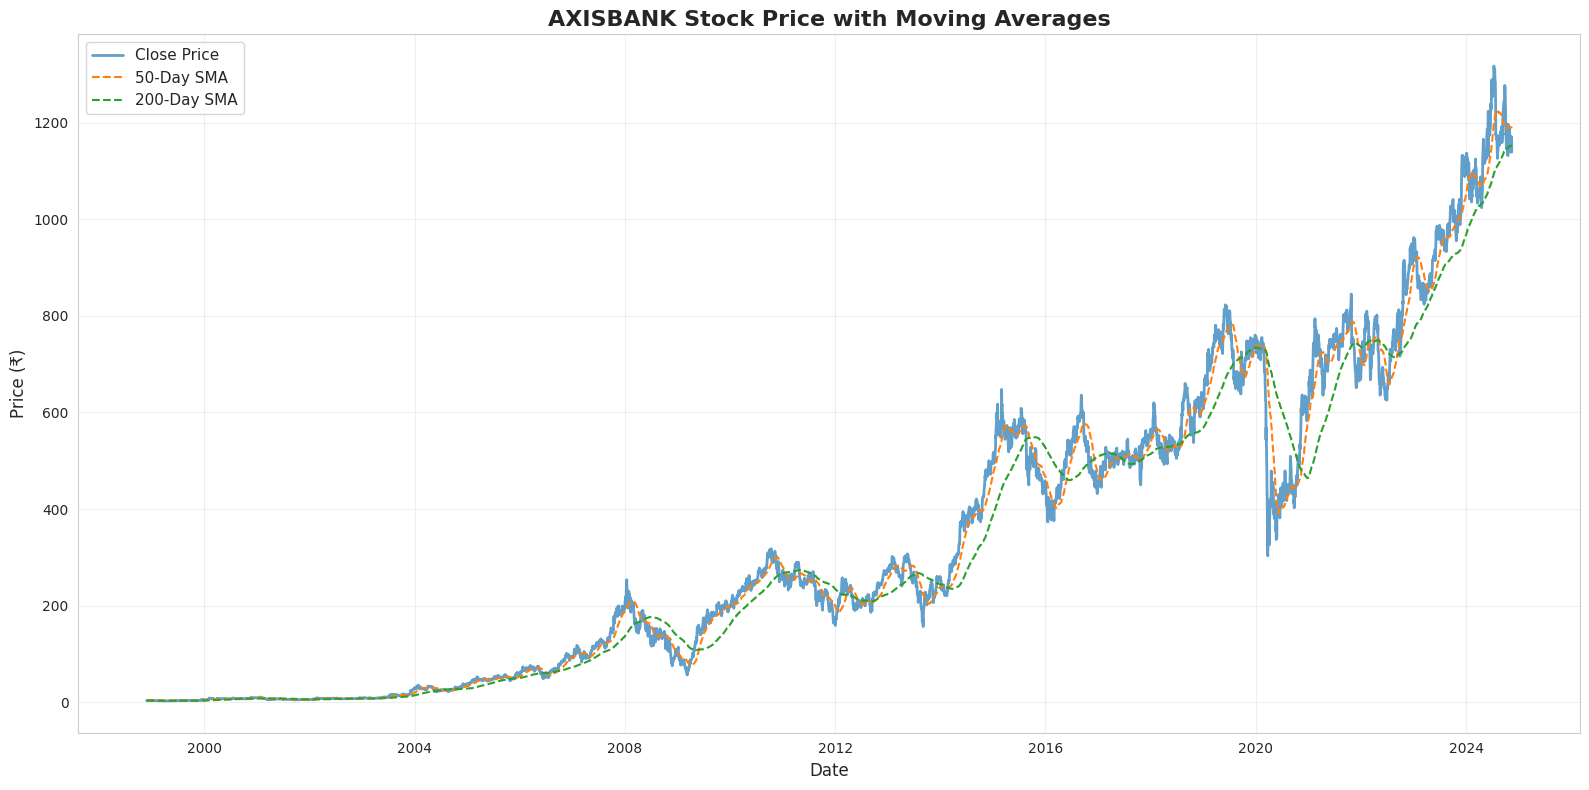


Note: Golden Cross (SMA_50 > SMA_200) indicates bullish signal


In [115]:
# convert to Pandas for visualizationprint
print(" Visualization: Price Trend with Moving Averages ")
df_plot = df_cleaned.select("Date", "Close", "SMA_50", "SMA_200").orderBy("Date").toPandas()

# create plot
plt.figure(figsize=(16, 8))
plt.plot(df_plot['Date'], df_plot['Close'], label='Close Price', linewidth=2, alpha=0.7)
plt.plot(df_plot['Date'], df_plot['SMA_50'], label='50-Day SMA', linewidth=1.5, linestyle='--')
plt.plot(df_plot['Date'], df_plot['SMA_200'], label='200-Day SMA', linewidth=1.5, linestyle='--')

plt.title('AXISBANK Stock Price with Moving Averages', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (₹)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNote: Golden Cross (SMA_50 > SMA_200) indicates bullish signal")

### Visualization 2: Bollinger Bands

Visualization: Bollinger Bands


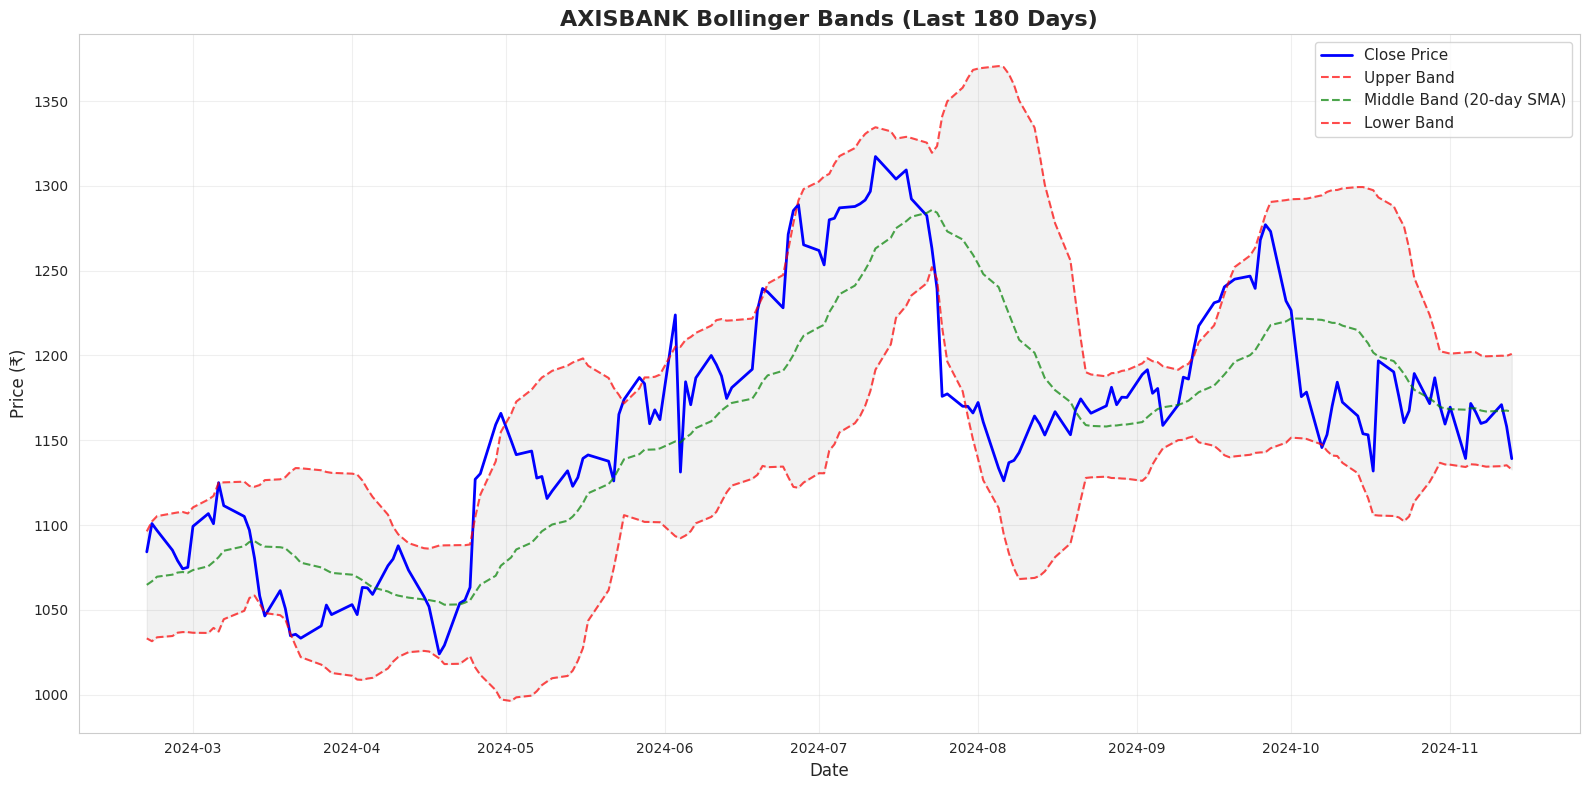


Note: Price touching upper band = potentially overbought
      Price touching lower band = potentially oversold


In [116]:
# bollinger Bands visualization
print("Visualization: Bollinger Bands")
df_bb = df_bollinger.select("Date", "Close", "BB_Upper", "BB_Middle", "BB_Lower").orderBy("Date").toPandas()

# plot last 180 days for better visibility
df_bb_recent = df_bb.tail(180)

plt.figure(figsize=(16, 8))
plt.plot(df_bb_recent['Date'], df_bb_recent['Close'], label='Close Price', color='blue', linewidth=2)
plt.plot(df_bb_recent['Date'], df_bb_recent['BB_Upper'], label='Upper Band', color='red', linestyle='--', alpha=0.7)
plt.plot(df_bb_recent['Date'], df_bb_recent['BB_Middle'], label='Middle Band (20-day SMA)', color='green', linestyle='--', alpha=0.7)
plt.plot(df_bb_recent['Date'], df_bb_recent['BB_Lower'], label='Lower Band', color='red', linestyle='--', alpha=0.7)

# fill between bands
plt.fill_between(df_bb_recent['Date'], df_bb_recent['BB_Upper'], df_bb_recent['BB_Lower'], alpha=0.1, color='gray')

plt.title('AXISBANK Bollinger Bands (Last 180 Days)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (₹)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNote: Price touching upper band = potentially overbought")
print("      Price touching lower band = potentially oversold")

### Visualization 3: Daily Returns Distribution

Daily Returns Distribution


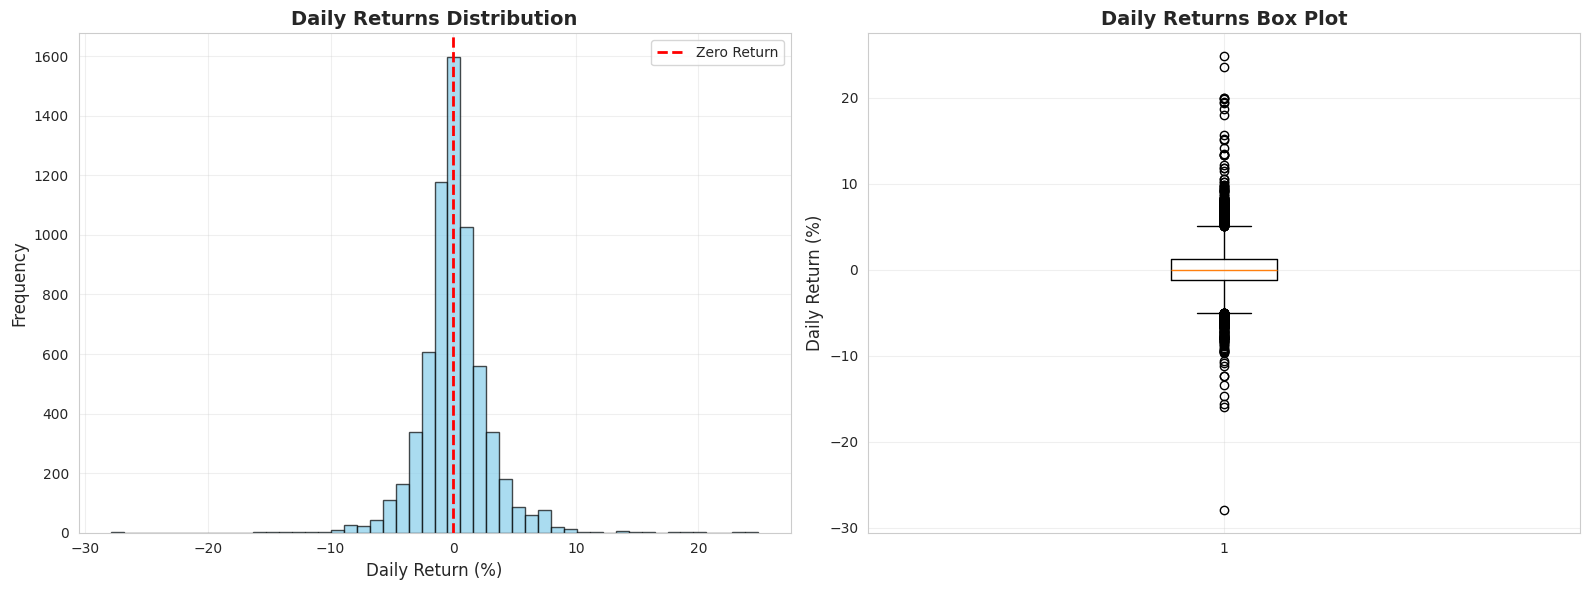


Daily Return Statistics:
  Mean: 0.1271%
  Std Dev: 2.7517%
  Skewness: 0.6382
  Kurtosis: 8.3897


In [118]:
# daily Returns distribution
print("Daily Returns Distribution")
df_returns = df_cleaned.select("Daily_Return").filter(col("Daily_Return").isNotNull()).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# histogram
axes[0].hist(df_returns['Daily_Return'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Return')
axes[0].set_title('Daily Returns Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Daily Return (%)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# box plot
axes[1].boxplot(df_returns['Daily_Return'], vert=True)
axes[1].set_title('Daily Returns Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Daily Return (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# stats
print(f"\nDaily Return Statistics:")
print(f"  Mean: {df_returns['Daily_Return'].mean():.4f}%")
print(f"  Std Dev: {df_returns['Daily_Return'].std():.4f}%")
print(f"  Skewness: {df_returns['Daily_Return'].skew():.4f}")
print(f"  Kurtosis: {df_returns['Daily_Return'].kurtosis():.4f}")

### Visualization 4: Volume Analysis

Volume and Price Trends


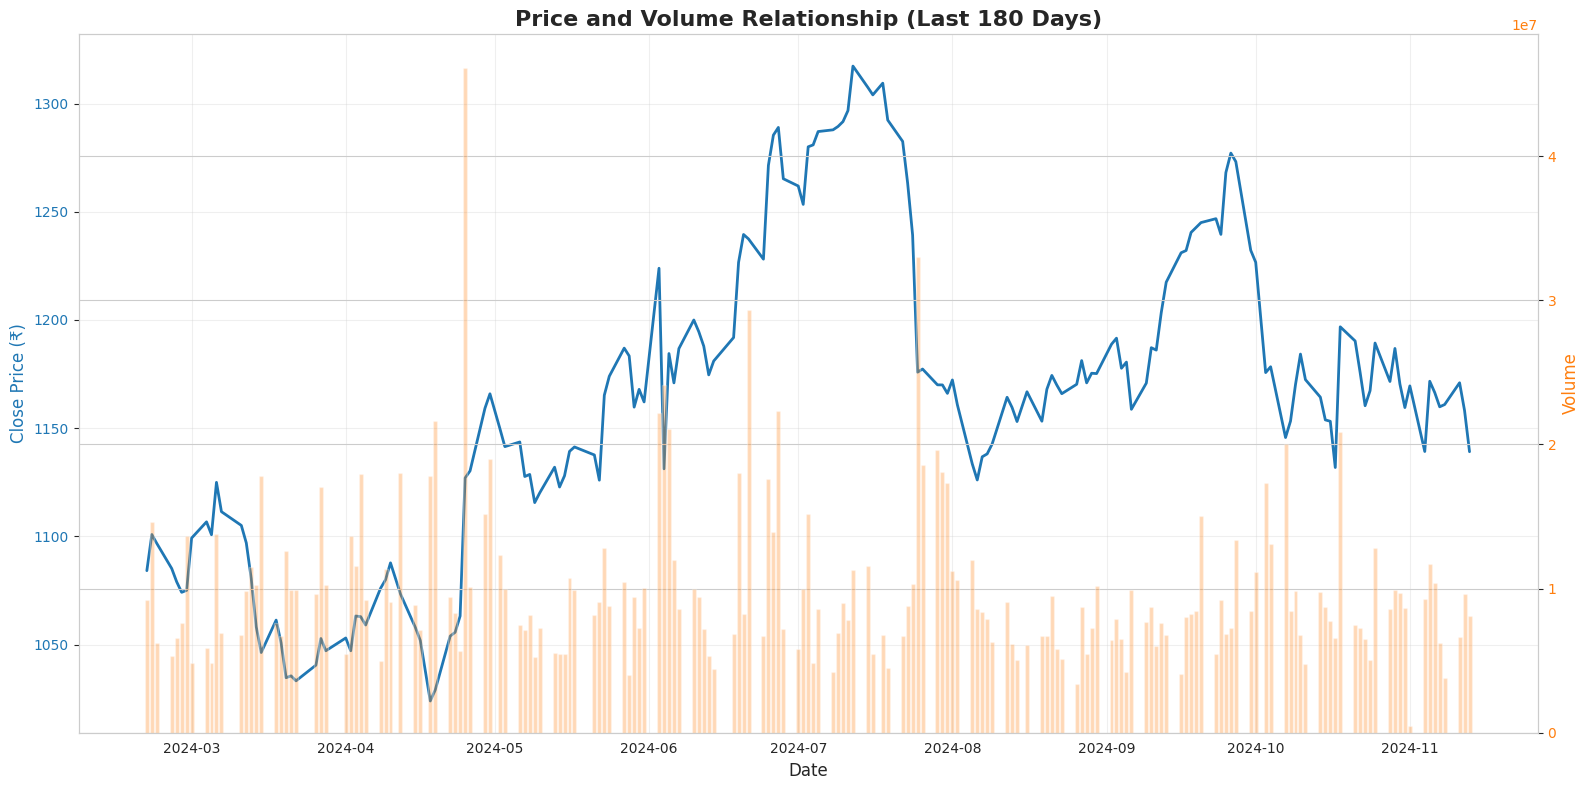


Note: Volume spikes often occur during significant price movements


In [119]:
# Volume and Price relationship
print("Volume and Price Trends")
df_vol = df_cleaned.select("Date", "Close", "Volume").orderBy("Date").toPandas()

# Recent data for better visibility
df_vol_recent = df_vol.tail(180)

fig, ax1 = plt.subplots(figsize=(16, 8))

# Price on primary y-axis
color = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Close Price (₹)', color=color, fontsize=12)
ax1.plot(df_vol_recent['Date'], df_vol_recent['Close'], color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Volume on secondary y-axis
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Volume', color=color, fontsize=12)
ax2.bar(df_vol_recent['Date'], df_vol_recent['Volume'], color=color, alpha=0.3)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Price and Volume Relationship (Last 180 Days)', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()

print("\nNote: Volume spikes often occur during significant price movements")

### Visualization 5: Correlation Heatmap

Correlation Matrix


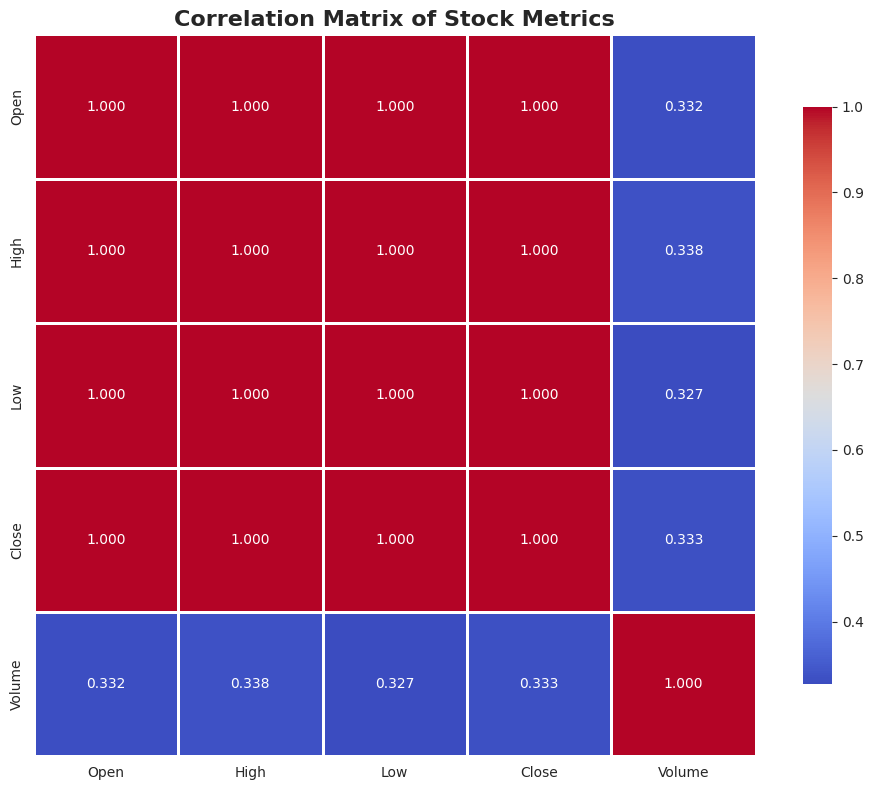


Note: Values close to +1 indicate strong positive correlation
      Values close to -1 indicate strong negative correlation
      Values close to 0 indicate weak or no correlation


In [120]:
# Correlation heatmap
print("Correlation Matrix")
df_corr = df_cleaned.select("Open", "High", "Low", "Close", "Volume").toPandas()

# Calculate correlation
correlation_matrix = df_corr.corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Stock Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNote: Values close to +1 indicate strong positive correlation")
print("      Values close to -1 indicate strong negative correlation")
print("      Values close to 0 indicate weak or no correlation")

### Visualization 6: Monthly Performance

Monthly Average Close Price


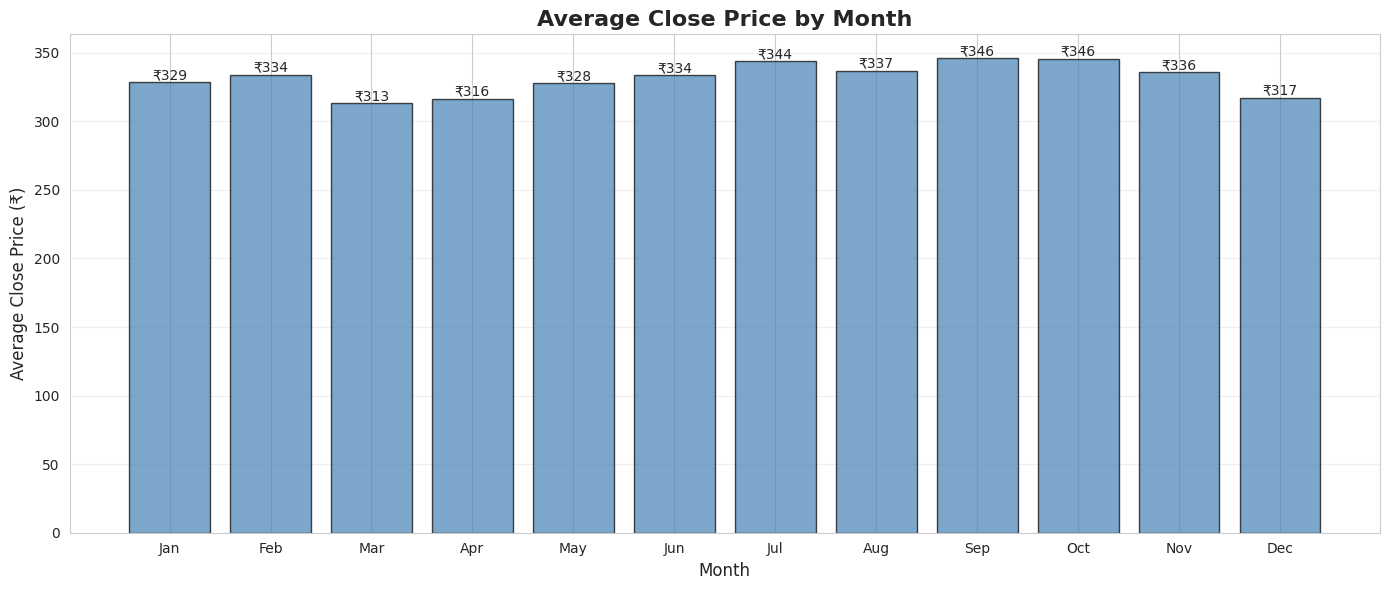


Note: Helps identify seasonal patterns in stock performance


In [121]:
# Monthly average performance
print("Monthly Average Close Price")
df_month = df_monthly.groupBy("Month").agg(avg("Close").alias("Avg_Close")).orderBy("Month").toPandas()

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_month['Month_Name'] = df_month['Month'].apply(lambda x: months[int(x)-1] if x <= 12 else 'Unknown')

plt.figure(figsize=(14, 6))
bars = plt.bar(df_month['Month_Name'], df_month['Avg_Close'], color='steelblue', edgecolor='black', alpha=0.7)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'₹{height:.0f}',
             ha='center', va='bottom', fontsize=10)

plt.title('Average Close Price by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Close Price (₹)', fontsize=12)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNote: Helps identify seasonal patterns in stock performance")

### Visualization 7: Forecast vs Actual Price Comparison

Actual vs Forecasted Prices


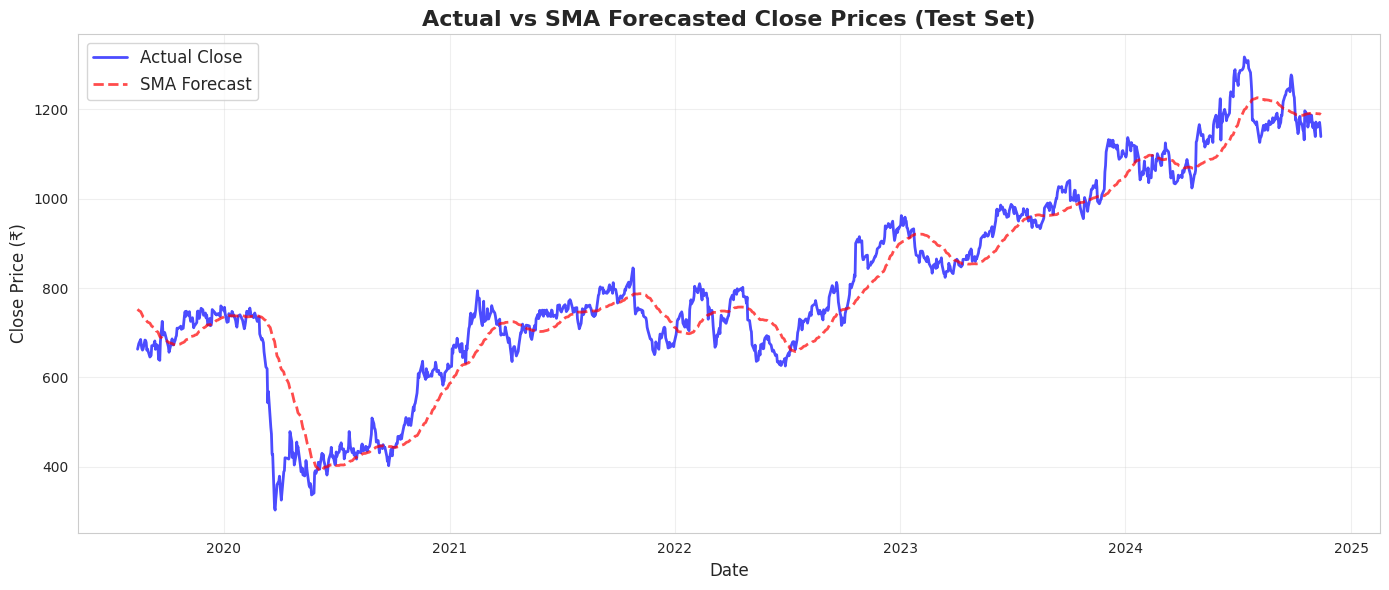


Forecast Metrics:
MAE: ₹45.09
RMSE: ₹60.34
MAPE: 6.50%

Note: Lower values indicate better forecast accuracy


In [122]:
# Compare actual vs forecasted prices
print("Actual vs Forecasted Prices")
forecast_comparison_pd = test_with_forecast.select("Date", col("Close").alias("Actual_Close"), "Forecast_SMA").orderBy("Date").toPandas()

plt.figure(figsize=(14, 6))
plt.plot(forecast_comparison_pd['Date'], forecast_comparison_pd['Actual_Close'],
         label='Actual Close', color='blue', linewidth=2, alpha=0.7)
plt.plot(forecast_comparison_pd['Date'], forecast_comparison_pd['Forecast_SMA'],
         label='SMA Forecast', color='red', linestyle='--', linewidth=2, alpha=0.7)

plt.title('Actual vs SMA Forecasted Close Prices (Test Set)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price (₹)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nForecast Metrics:")
print(f"MAE: ₹{mae:.2f}")
print(f"RMSE: ₹{rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print("\nNote: Lower values indicate better forecast accuracy")

---

## Summary of Visualizations

All visualizations created successfully:
1. **Stock Price Trend with Moving Averages** - Shows price movements and trend indicators
2. **Bollinger Bands** - Displays volatility and price boundaries
3. **Daily Returns Distribution** - Reveals return patterns and outliers
4. **Volume vs Price Relationship** - Correlates trading activity with price
5. **Correlation Heatmap** - Shows relationships between features
6. **Monthly Performance** - Identifies seasonal patterns
7. **Forecast Comparison** - Validates predictive model accuracy

---

##  Final Completion Checklist

### Mandatory Phases (All Complete):
- **Phase 1**: Data Understanding - RDD, DataFrame, SQL APIs
- **Phase 2**: Data Cleaning & Preparation - Date conversion, moving averages
- **Phase 3**: Exploratory Data Analysis - Volatility, patterns, volume analysis
- **Phase 4**: Correlation & Trend Analysis - Correlation matrix, crossovers, Bollinger Bands
- **Phase 5**: Advanced Analysis - Price alerts, volume quartiles
- **Phase 6**: Strategic Insights & Recommendations - Investment strategies

### Optional Phases (All Complete):
- **Phase 5 (Optional)**: Time-Series Forecasting - SMA/EMA forecasting with metrics
- **Phase 7 (Optional)**: Presentation & Documentation - 7 comprehensive visualizations


---